In [20]:
!pip install pandas numpy matplotlib seaborn scipy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 5.6 MB/s eta 0:00:0000:0100:01m


In [1]:
import pandas as pd
import re

# regex para extrair campos do log
pattern = re.compile(
    r'(?:(\d+),)?"?'
    r'(?P<ip>\S+) \S+ \S+ '
    r'\[(?P<time>[^\]]+)\] '
    r'""?(?P<method>\S+) (?P<url>\S+) (?P<protocol>[^"]+)"" '
    r'(?P<status>\d{3}) '
    r'(?P<size>\d+) '
    r'""(?P<referer>[^"]*)"" '
    r'""(?P<agent>[^"]*)"" '
)

data = []

with open("access.log", "r", encoding="utf-8", errors="ignore") as f:
    for line in f:
        match = pattern.search(line)
        if match:
            row = match.groupdict()
            row["id"] = match.group(1)
            data.append(row)

df = pd.DataFrame(data)

# converter tipos
df["status"] = df["status"].astype(int)
df["size"] = df["size"].astype(int)

# converter data
df["time"] = pd.to_datetime(df["time"], format="%d/%b/%Y:%H:%M:%S %z")

print(df.head())
print(df.info())

               ip                      time method  \
0  ,"54.36.149.41 2019-01-22 03:56:14+03:30    GET   
1   5.210.140.170 2019-01-23 12:43:40+03:30    GET   
2    66.249.66.91 2019-01-24 21:17:43+03:30    GET   
3    5.200.69.130 2019-01-26 13:54:06+03:30    GET   
4    5.208.174.46 2019-01-23 22:52:04+03:30    GET   

                                                 url  protocol  status   size  \
0  /filter/27|13%20%D9%85%DA%AF%D8%A7%D9%BE%DB%8C...  HTTP/1.1     200  30577   
1                      /apple-touch-icon-120x120.png  HTTP/1.1     404  33679   
2            /static/images/guarantees/bestPrice.png  HTTP/1.1     304      0   
3                                     /image/1/brand  HTTP/1.1     200   3924   
4                        /image/1221/mainSlideMobile  HTTP/1.1     200  68387   

                                             referer  \
0                                                  -   
1                                                  -   
2                   

In [2]:
df

,ip,time,method,url,protocol,status,size,referer,agent,id
0,",""54.36.149.41",2019-01-22 03:56:14+03:30,GET,/filter/27|13%20%D9%85%DA%AF%D8%A7%D9%BE%DB%8C...,HTTP/1.1,200,30577,-,Mozilla/5.0 (compatible; AhrefsBot/6.1; +http:...,NaN
1,5.210.140.170,2019-01-23 12:43:40+03:30,GET,/apple-touch-icon-120x120.png,HTTP/1.1,404,33679,-,MobileSafari/604.1 CFNetwork/976 Darwin/18.2.0,3089189
2,66.249.66.91,2019-01-24 21:17:43+03:30,GET,/static/images/guarantees/bestPrice.png,HTTP/1.1,304,0,-,Googlebot-Image/1.0,6073343
3,5.200.69.130,2019-01-26 13:54:06+03:30,GET,/image/1/brand,HTTP/1.1,200,3924,"https://www.zanbil.ir/filter/b1,p62",Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,9392152
4,5.208.174.46,2019-01-23 22:52:04+03:30,GET,/image/1221/mainSlideMobile,HTTP/1.1,200,68387,https://www.zanbil.ir/m/browse/cell-phone/%DA%...,Mozilla/5.0 (Linux; Android 6.0.1; SAMSUNG SM-...,4366289
...,...,...,...,...,...,...,...,...,...,...
9996,188.210.134.93,2019-01-26 12:50:09+03:30,GET,/static/images/amp/telegram.png,HTTP/1.1,200,4859,"https://www.zanbil.ir/filter/b2,p6",Mozilla/5.0 (Windows NT 10.0; rv:64.0) Gecko/2...,9188987
9997,37.148.18.31,2019-01-25 20:26:30+03:30,GET,/image/1131/article/100x100,HTTP/1.1,200,18345,https://www.zanbil.ir/browse/audio-and-video-e...,Mozilla/5.0 (Windows NT 6.1; Win64; x64; rv:64...,7782398
9998,66.249.66.91,2019-01-24 00:18:42+03:30,GET,/filter/b481%2Cb874%2Cb226%2Cb570%2Cb80%2Cb270...,HTTP/1.1,200,41096,-,Mozilla/5.0 (compatible; Googlebot/2.1; +http:...,4514535
9999,46.62.180.218,2019-01-22 09:08:08+03:30,GET,/image/62562/productModel/100x100,HTTP/1.1,200,1502,https://www.zanbil.ir/product/33889/64618/%DB%...,Mozilla/5.0 (Windows NT 6.1) AppleWebKit/537.3...,211635


In [3]:
import numpy as np

# latência baseada no tamanho da resposta
lat_size = df["size"] / 120   # ajuste do fator conforme desejar

# ruído aleatório (variabilidade da rede)
noise = np.random.normal(50, 15, len(df))

# penalidade para erros
penalty = np.where(
    df["status"] >= 500, np.random.normal(800,150,len(df)),
    np.where(
        df["status"] >= 400, np.random.normal(400,80,len(df)),
        np.random.normal(100,20,len(df))
    )
)

# latência final
df["latency_ms"] = lat_size + penalty + noise

# evitar valores negativos
df["latency_ms"] = df["latency_ms"].clip(lower=1)

In [4]:
df.describe()

,status,size,latency_ms
count,10001.000000,10001.000000,10001.000000
mean,210.496250,12635.964004,261.439121
std,39.882069,29465.995701,251.151366
min,200.000000,0.000000,70.314788
25%,200.000000,1990.000000,162.904461
50%,200.000000,4120.000000,191.635395
75%,200.000000,11617.000000,263.437972
max,502.000000,565547.000000,4857.701636


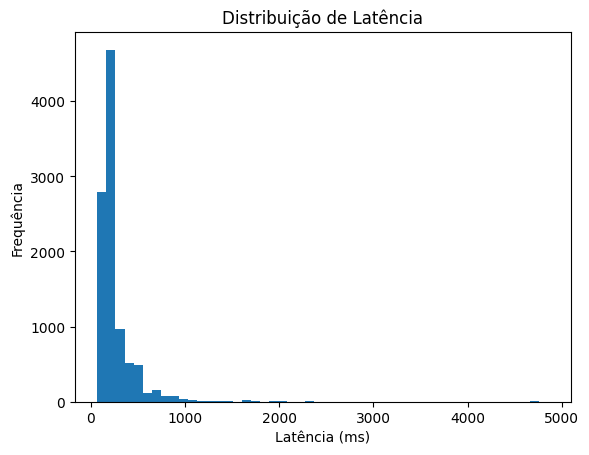

In [5]:
import matplotlib.pyplot as plt

plt.hist(df["latency_ms"], bins=50)

plt.xlabel("Latência (ms)")
plt.ylabel("Frequência")
plt.title("Distribuição de Latência")

plt.show()

In [6]:
from datetime import datetime

def format_time(t):
    return t.strftime("%d/%b/%Y:%H:%M:%S %z")

with open("access_with_latency.log", "w", encoding="utf-8") as f:

    for _, row in df.iterrows():

        time_str = format_time(row["time"])

        line = (
            f'{int(row["id"]) if not pd.isna(row["id"]) else ""},'
            f'"{row["ip"]} - - [{time_str}] '
            f'""{row["method"]} {row["url"]} {row["protocol"]}"" '
            f'{row["status"]} {row["size"]} '
            f'""{row["referer"]}"" '
            f'""{row["agent"]}"" '
            f'""-"" '
            f'{round(row["latency_ms"],2)}'
            f'"'
        )

        f.write(line + "\n")